# Explore nested-EAGLE CONUS forecasts

The **nested-Experimental Artificial Intelligence Global and Limited-area Ensemble (nested-EAGLE)** is an experimental machine-learning weather forecast system developed through a joint effort between NOAA Research Laboratories, the Earth Prediction Innovation Center (EPIC), and the National Weather Service (NWS). Built with the ECMWF and partner agencies' Anemoi framework, it combines a 0.25-degree global model with a higher-resolution nested domain over the contiguous United States (CONUS).

This tutorial demonstrates how to discover nested-EAGLE CONUS forecast items in the Microsoft Planetary Computer STAC catalog, open a signed remote netCDF asset with Xarray, transform the projected grid to longitude and latitude coordinates, select surface and pressure-level fields, create maps, and animate a forecast sequence.

## Dataset at a glance

- **Coverage:** October 1, 2024 to present
- **CONUS grid:** 6 km resolution on the High-Resolution Rapid Refresh (HRRR) Lambert Conformal Conic (LCC) grid
- **Initialization:** Four cycles daily at 00, 06, 12, and 18 Z, typically available about six hours later
- **Forecast horizon:** 10 days (240 hours) at 6-hour intervals
- **Format:** One netCDF file per forecast, with 2D surface, 10 m, and 80 m fields plus 3D atmospheric fields on 12 pressure levels from 100 to 1000 hPa

The collection is provided free of charge on an unsupported, experimental basis. It should not be used for critical operational decisions.

**Producer:** NOAA EPIC  
**Host:** Microsoft Planetary Computer

**Citation:** The Earth Prediction Innovation Center (EPIC) and the NOAA AI for Numerical Weather Prediction (AI4NWP) Working Group. (2026). *The nested-EAGLE (Experimental AI Global and Limited-area Ensemble forecast system) v1.1.0*. Zenodo. [https://doi.org/10.5281/zenodo.19672026](https://doi.org/10.5281/zenodo.19672026)

Load required imports and set variables used throughout the rest of the notebook.

In [ ]:
%pip install requests aiohttp xarray fsspec matplotlib cartopy h5netcdf h5py dask pillow

In [1]:
import requests
from io import BytesIO
import xarray as xr
from datetime import datetime, timezone, timedelta
import fsspec
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import pyproj
import numpy as np

# chose forecasts you wish to load
# code will filter stac item search to initializations between start and stop
init_start = "2025-01-31T18:00:00"
init_stop = "2025-02-02T18:00:00"

# chose forecast and the amount of lead time you wish to plot.
init_to_plot = datetime(2025, 1, 31, 18, tzinfo=timezone.utc)
# easy-to-edit lead times
forecast_start_lead = timedelta(hours=0) # set to 0 to start with initial conditions
forecast_stop_lead = timedelta(hours=72) # max is 240

variables_to_load = [
    "2m_temperature",
    "total_precipitation_6hr",
    "meridional_wind",
    "crs", # required for loading lat/lon info later
]
level_to_load = 500

Load STAC items from Planetary *Computer*

In [2]:
# call the nested-eagle API
response = requests.post(
    "https://planetarycomputer.microsoft.com/stac/search",
    json={
        "collections": ["nested-eagle-conus"],
        "filter-lang": "cql2-json",
        "datetime": f"{init_start}Z/{init_stop}Z",
    },
    headers={
        "Content-Type": "application/json"},
    params={
        "api-version": "2026-04-15",
        "sign": "true",
    },
)

matching_items = response.json()["features"]

print(len(matching_items))

49


Load a single forecast

In [3]:
init_str = init_to_plot.strftime("%Y%m%d-%Hz")
forecast_start = (init_to_plot + forecast_start_lead).strftime("%Y-%m-%dT%H:%M:%S")
forecast_stop = (init_to_plot + forecast_stop_lead).strftime("%Y-%m-%dT%H:%M:%S")

item = next(
    (entry for entry in matching_items if entry["id"].endswith(init_str)),
    None,
)

asset_href = item["assets"]["conus"]["href"]

with fsspec.open(
    asset_href,
    mode="rb",
    block_size=1024 * 1024,
) as remote_file:
    with xr.open_dataset(
        remote_file,
        engine="h5netcdf",
        chunks={},
    ) as full_ds:
        ds = (
            full_ds[variables_to_load]
            .sel(
              time=slice(forecast_start,forecast_stop),
              level=level_to_load,
            )
            .load()
        )

Create lat/lon coordinates for the curvilinear grid

In [4]:
# build 2D x/y grid
xx, yy = np.meshgrid(ds["x"].values, ds["y"].values)

# source CRS from the WKT string in the dataset
src_crs = pyproj.CRS.from_wkt(ds["crs"].attrs["spatial_ref"])

# target CRS: lon/lat
dst_crs = pyproj.CRS.from_epsg(4326)

transformer = pyproj.Transformer.from_crs(
    src_crs,
    dst_crs,
    always_xy=True,
)

lon, lat = transformer.transform(xx, yy)

# add lon/lat as 2D coordinates
ds = ds.assign_coords(
    lon=(("y", "x"), lon),
    lat=(("y", "x"), lat),
)

ds

<xarray.Dataset> Size: 70MB
Dimensions:                  (time: 13, y: 480, x: 848)
Coordinates:
  * time                     (time) datetime64[ns] 104B 2025-01-31T18:00:00 ....
  * y                        (y) float64 4kB -1.436e+06 -1.43e+06 ... 1.438e+06
  * x                        (x) float64 7kB -2.546e+06 -2.54e+06 ... 2.536e+06
    lon                      (y, x) float64 3MB -121.7 -121.7 ... -63.68 -63.6
    lat                      (y, x) float64 3MB 22.75 22.76 ... 47.17 47.15
    level                    int64 8B 500
Data variables:
    2m_temperature           (time, y, x) float32 21MB 290.2 290.2 ... 270.9
    total_precipitation_6hr  (time, y, x) float32 21MB nan nan ... 1.258 1.294
    meridional_wind          (time, y, x) float32 21MB -5.053 -5.191 ... 7.471
    crs                      int64 8B 0
Attributes:
    forecast_reference_time:  2025-01-31T18:00:00.000000000
    description:              Output from NOAA's Nested-EAGLE forecast model ...
    grid_projection:          Lambert Conic Conformal (LCC)
    horizontal_resolution:    6km
    version:                  1.0
    Conventions:              CF-1.8

Plot a surface variable

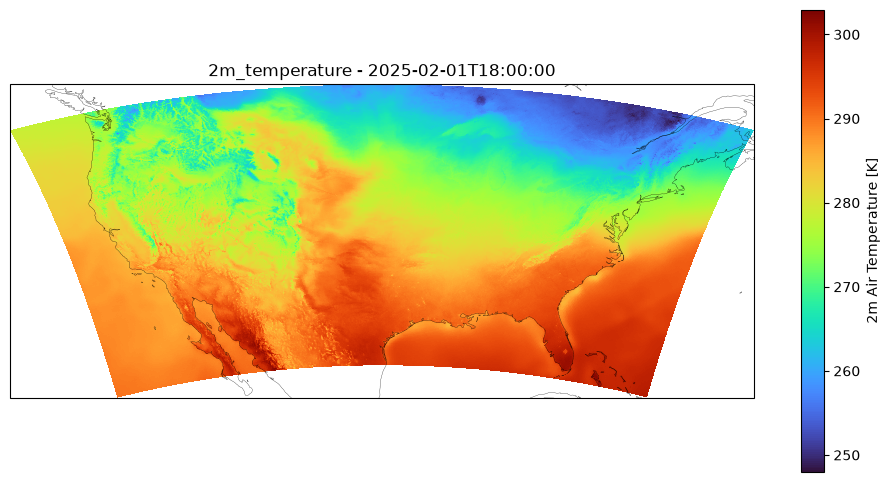

In [5]:
var_to_plot = "2m_temperature" # can change to meridional wind or precipitation.
time_to_plot = "2025-02-01T18:00:00" # can change to a different hour in your forecast.

field = ds[var_to_plot].sel(
    time=time_to_plot,
).squeeze()

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

field.plot.pcolormesh(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo"
)

plt.title(f"{var_to_plot} - {time_to_plot}")

ax.coastlines(linewidth=0.2)
plt.show()

Plot a pressure level

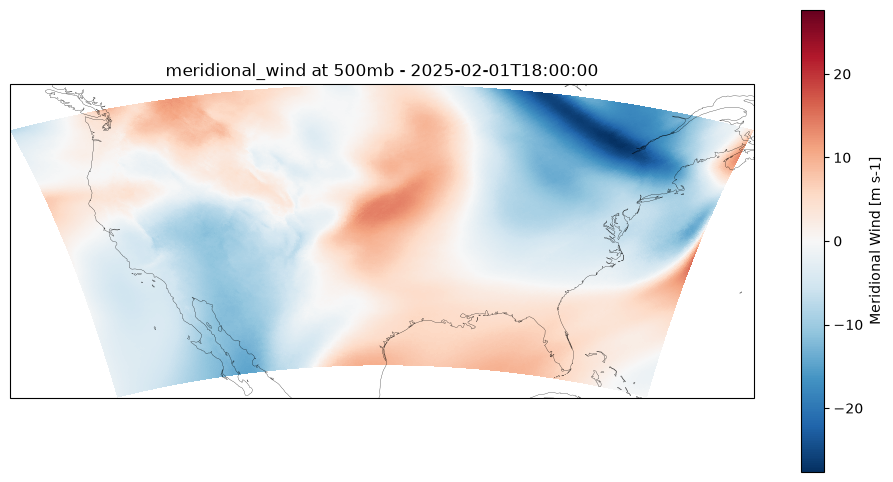

In [6]:
var_to_plot = "meridional_wind" # can change to meridional wind or precipitation.
time_to_plot = "2025-02-01T18:00:00" # can change to a different hour in your forecast.

field = ds[var_to_plot].sel(
    time=time_to_plot,
).squeeze()

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

field.plot.pcolormesh(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r"
)

plt.title(f"{var_to_plot} at {level_to_load}mb - {time_to_plot}")

ax.coastlines(linewidth=0.2)
plt.show()

Plot a GIF of an Atmospheric River Event

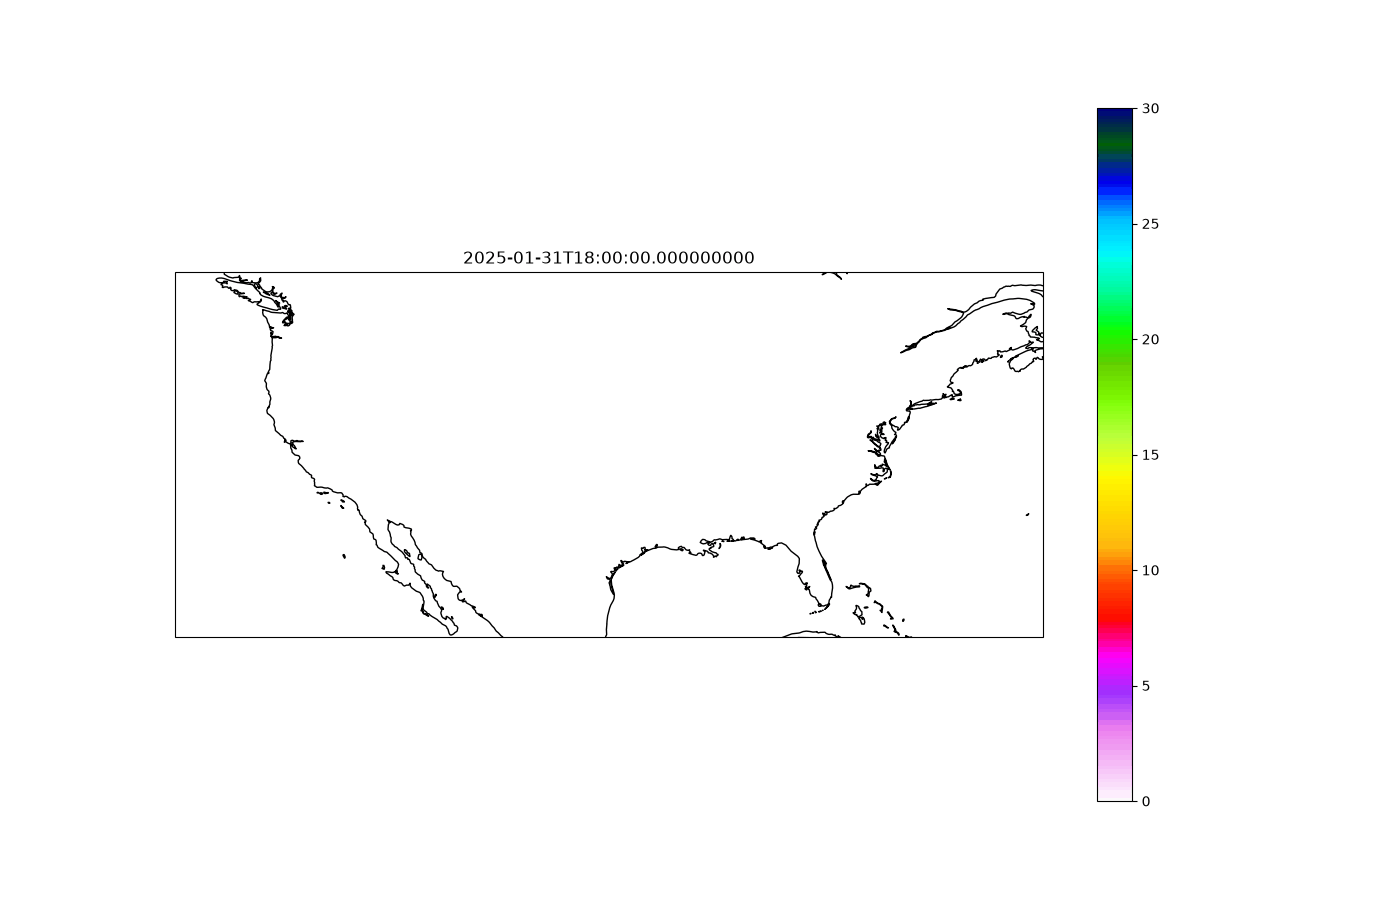

In [7]:
var_to_plot = "total_precipitation_6hr"

field = ds[var_to_plot]

fig, ax = plt.subplots(
    figsize=(14, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

mesh = ax.pcolormesh(
    ds.lon,
    ds.lat,
    field.isel(time=0),
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="gist_ncar_r",
    vmin=0,
    vmax=30,
)

ax.coastlines()
plt.colorbar(mesh, ax=ax)

def update(i):
    mesh.set_array(field.isel(time=i).values.ravel())
    ax.set_title(str(field.time.values[i]))
    return mesh,

animation = FuncAnimation(
    fig,
    update,
    frames=len(field.time),
    interval=250,
)

animation.save("event.gif", writer=PillowWriter(fps=4))

plt.close(fig)

Image(filename="event.gif")